In [8]:
# CARGA DE DATOS #

import pandas as pd
import matplotlib.pyplot as plt


# test comment
# Ruta al archivo de Excel
archivo_excel = './IIYNT-REQ-BD-001.xlsx' #../

# Número de la fila desde la cual querés empezar (0-indexado)
fila_inicio = 3

# Leer el archivo Excel
init_df = pd.read_excel(archivo_excel)

# Mostrar las primeras filas del DataFrame para confirmar que se leyó bien
init_df.head()

# TRANSFORMACIÓN DE DATOS #

desired_columns = [
    'Temperatura Ambiental (°C)', 
    'Humedad',
    'Temperatura de la muestra (°C)', 
    'pH', 
    'CE\n(µS/cm)', 
    'STD\n(mg/L)',
    'STS\n(mL sed/L)', 
    'OD\n(mg/L)', 
    'Nivel (cm)', 
    'Turbidez (NTU)',
    'Dureza\n(mg CaCO3/L)', 
    'Cloruros\n(mg Cl-/L)'
]
df = init_df.iloc[2:272][desired_columns]
df


,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
2,16,0.929,18,8.2,1240,610,NaN,5.37,NaN,NaN,NaN,NaN
3,17,0.47,19,8.3,1630,810,1.8,4.3,NaN,NaN,147,156
4,11.9,0.47,13,8.1,1000,490,18,5.3,NaN,41.2,94,78
5,11.9,0.47,13,8.2,1000,490,18,4.67,NaN,38.9,86,82
6,11.9,0.47,13,8.3,1350,670,0.1,7.01,NaN,30.7,200,117
...,...,...,...,...,...,...,...,...,...,...,...,...
269,11,0.51,13.1,8.1,900,440,10,1.68,55,1.4,NaN,NaN
270,11,0.51,13,7.8,1070,530,20,1.32,55,31.5,NaN,NaN
271,11,0.51,13.1,8,1100,540,20,2.22,55,28.3,NaN,NaN
272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
#Eliminar las filas que tienen valores nulos o no asignados
#df.dropna(inplace=True) #aca se modifica el Dataframe original con inplace=true

#Si asigno a nueva variable no hace falta inplace=true pero no modifica el Dataframe original
df_sin_nulos=df.dropna()

#Como opcion puedo llenar los valores nulos con datos adecuados: 
#fillna(method='bfill') (llenar con el valor siguiente de la columna)
#fillna(method='ffill') (llenar con el valor anterior de la columna)
#fillna(0) (llenar con ceros) 

""" mediaNivel=df['Nivel (cm)'].mean()
df['Nivel (cm)']=df['Nivel (cm)'].fillna(mediaNivel)

mediaSTS=df['STS\n(mL sed/L)'].mean()
df['STS\n(mL sed/L)']=df['STS\n(mL sed/L)'].fillna(mediaSTS)

mediaTurbidez=df['Turbidez (NTU)'].mean()
df['Turbidez (NTU)']=df['Turbidez (NTU)'].fillna(mediaTurbidez)

mediaDureza=df['Dureza\n(mg CaCO3/L)'].mean()
df['Dureza\n(mg CaCO3/L)']=df['Dureza\n(mg CaCO3/L)'].fillna(mediaDureza)

mediaCloruros=df['Cloruros\n(mg Cl-/L)'].mean()
df['Cloruros\n(mg Cl-/L)']=df['Cloruros\n(mg Cl-/L)'].fillna(mediaCloruros)
"""
#df_sin_nulos=df
df_sin_nulos.isna().sum()
#df_sin_nulos.head()
df_sin_nulos

,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
42,18,0.6,17.75,7.9,1210,600,92,1.79,27.5,1000,114,97
43,18,0.6,18.05,7.7,1170,580,92,1.35,27.5,1000,114,95
44,18,0.6,18.15,8.1,1000,490,50,4.97,27.5,238,135,79
45,18,0.6,18.15,8.1,1000,490,50,3.12,27.5,351,139,81
46,18,0.6,18.2,8.2,1310,640,64,1.71,47.5,95.6,135,120
...,...,...,...,...,...,...,...,...,...,...,...,...
215,30.5,0.5,27.6,8.2,1570,780,30,0.96,30,10.6,223,166
216,30.5,0.5,27.6,8,1530,760,40,0.52,40,19.6,194,150
217,30.5,0.5,27.6,7.9,1530,760,40,0.47,40,21.3,194,150
218,30.5,0.5,27.6,7.8,1050,520,1,1.34,25,1.06,245,71


In [10]:
def min_max_info(dataframe: pd.DataFrame) -> pd.DataFrame:
    name = list()
    minimums = list()
    maximums = list()
    for i, key in enumerate(dataframe.columns):
        name.append(key)
        minimums.append(dataframe[key].min())
        maximums.append(dataframe[key].max())
    return pd.DataFrame(
        {
            'name': name,
            'mins': minimums,
            'maxs': maximums
        }
    )
min_max_info(df_sin_nulos)

,name,mins,maxs
0,Temperatura Ambiental (°C),12.80,30.50
1,Humedad,0.19,0.87
2,Temperatura de la muestra (°C),15.10,28.10
3,pH,7.30,8.70
4,CE\n(µS/cm),200.00,1710.00
5,STD\n(mg/L),140.00,850.00
6,STS\n(mL sed/L),1.00,620.00
7,OD\n(mg/L),0.00,9.12
8,Nivel (cm),10.00,70.00
9,Turbidez (NTU),1.06,1000.00


In [11]:
def normalize(dataframe: pd.DataFrame, min: float, max: float) -> pd.DataFrame:
    return (dataframe - min) / (max - min)

def denormalize(dataframe: pd.DataFrame, min: float, max: float) -> pd.DataFrame:
    return dataframe * (max - min) + min


def normalizer(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    df['Temperatura Ambiental (°C)']                = normalize(df['Temperatura Ambiental (°C)'],       min=0, max=40)
    df['Humedad'] = df['Humedad']
    df['Temperatura de la muestra (°C)']            = normalize(df['Temperatura de la muestra (°C)'],   min=0, max=40)
    df['pH']                                        = normalize(df['pH'],                               min=6, max=10)
    df['CE\n(µS/cm)']                               = normalize(df['CE\n(µS/cm)'],                      min=100, max=2000)
    df['STD\n(mg/L)']                               = normalize(df['STD\n(mg/L)'],                      min=100, max=1000)
    df['STS\n(mL sed/L)']                           = normalize(df['STS\n(mL sed/L)'],                  min=0, max=1000)
    df['OD\n(mg/L)']                                = normalize(df['OD\n(mg/L)'],                       min=0, max=10)
    df['Nivel (cm)']                                = normalize(df['Nivel (cm)'],                       min=0, max=100)
    df['Turbidez (NTU)']                            = normalize(df['Turbidez (NTU)'],                   min=0, max=1000)
    df['Dureza\n(mg CaCO3/L)']                      = normalize(df['Dureza\n(mg CaCO3/L)'],             min=50, max=500)
    df['Cloruros\n(mg Cl-/L)']                      = normalize(df['Cloruros\n(mg Cl-/L)'],             min=0, max=200)    
    return df

def denormalizer(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    df['Temperatura Ambiental (°C)']                = denormalize(df['Temperatura Ambiental (°C)'],       min=0, max=40)
    df['Humedad'] = df['Humedad']
    df['Temperatura de la muestra (°C)']            = denormalize(df['Temperatura de la muestra (°C)'],   min=0, max=40)
    df['pH']                                        = denormalize(df['pH'],                               min=6, max=10)
    df['CE\n(µS/cm)']                               = denormalize(df['CE\n(µS/cm)'],                      min=100, max=2000)
    df['STD\n(mg/L)']                               = denormalize(df['STD\n(mg/L)'],                      min=100, max=1000)
    df['STS\n(mL sed/L)']                           = denormalize(df['STS\n(mL sed/L)'],                  min=0, max=1000)
    df['OD\n(mg/L)']                                = denormalize(df['OD\n(mg/L)'],                       min=0, max=10)
    df['Nivel (cm)']                                = denormalize(df['Nivel (cm)'],                       min=0, max=100)
    df['Turbidez (NTU)']                            = denormalize(df['Turbidez (NTU)'],                   min=0, max=1000)
    df['Dureza\n(mg CaCO3/L)']                      = denormalize(df['Dureza\n(mg CaCO3/L)'],             min=50, max=500)
    df['Cloruros\n(mg Cl-/L)']                      = denormalize(df['Cloruros\n(mg Cl-/L)'],             min=0, max=200)    
    return df




In [12]:
from keras.layers import Input, Dense # tipos de capas de la red neuronal:
                                      # Dense = Conectado todo con todo
                                      # Input = Solo entrada
from keras.activations import sigmoid # Función de activación a la salida de la neurona
from keras.losses import mse # Tipo de ajuste de error (mean square error)
from keras.models import Model # Clase que devuelve la instancia del modelo
                               # el modelo es de la forma entrada -> salida
import numpy as np
import os as os

from tensorflow.keras.callbacks import TensorBoard # Interfaz Web de Tensorflow para visualizar
                                                   # grafico de entrenamiento
import shutil # Utilidad para manejo de consola
try:
    shutil.rmtree('./.logs') # Si existe, borro la carpeta .logs que es necesaria
                             # para la ingesta de tensorboard
except FileNotFoundError:
    pass
os.mkdir('./.logs') # creo una carpeta vacia
                    # para entrenar, ejecutar en consola y dentro del entorno virtual de python
                    # lo siguiente: tensorboard --logdir=./.logs
vector_size = len(df_sin_nulos.columns) # defino tamaño de vector de datos (en este caso 12 columnas)
dataset = np.array( # Lo hago matriz, papu
    normalizer(df_sin_nulos).astype(np.float16) # Normalizo el dataset inicial sin nulos y lo convierto a float de 16bit
)
encoded_size = 3 # Me invento un tamaño para el vector clasificador

# definimos modelo: (notación algebraica simulada: x = f(y))
# preguntar a chatGPT el tema de los shapes de keras porque es un lio
input_layer = Input(shape=(vector_size, )) # buscar en chatgpt maneras de construir una red neuronal con keras

x = Dense(4, activation=sigmoid)(input_layer) # se colocan unicamente 4 neuronas. Esto es prueba/error
# nota: Instancio la clase y la llamo, esto es un diseño "raro" de keras para que la definición
# de la red se "parezca" a una notacion matematica

encoded = Dense(encoded_size, activation=sigmoid)(x) #seria como la matriz de pesos por el vector de entrada x
x = Dense(4, activation=sigmoid)(encoded)
output = Dense(vector_size, activation=sigmoid)(x) # metodo call

autoencoder = Model(input_layer, output) # creo un modelo a partir de lo definido arriba
autoencoder.compile(optimizer='adam', loss='mse') # se compila el modelo
autoencoder.summary() # se imprime un resumen


2024-08-29 01:40:00.135137: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-29 01:40:00.136676: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-08-29 01:40:00.166571: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-08-29 01:40:00.168073: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-29 01:40:00.707014: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 12)]              0         
                                                                 
 dense (Dense)               (None, 4)                 52        
                                                                 
 dense_1 (Dense)             (None, 3)                 15        
                                                                 
 dense_2 (Dense)             (None, 4)                 16        
                                                                 
 dense_3 (Dense)             (None, 12)                60        
                                                                 
Total params: 143 (572.00 Byte)
Trainable params: 143 (572.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [14]:

tensorboard = TensorBoard(log_dir='./.logs') #creo instancia para guardar
epochs = 12000 # cantidad de veces a entranar o pasos para realizar el descenso del gradiente
autoencoder.fit(
    x=dataset,
    y=dataset,
    epochs=epochs,
    batch_size=len(dataset), #tamaño del bloque de entrenamiento
    shuffle=True,
    verbose=0, # que no envie salidas
    callbacks=[tensorboard]
    
)
    


In [15]:
generator = Model(encoded, output) #va del vector de clasificacion hasta la salida
generator.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 3)]               0         
                                                                 
 dense_2 (Dense)             (None, 4)                 16        
                                                                 
 dense_3 (Dense)             (None, 12)                60        
                                                                 
Total params: 76 (304.00 Byte)
Trainable params: 76 (304.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [16]:
encoder = Model(input_layer, encoded) #va desde el input a los datos codificados o clasificador
encoder.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 12)]              0         
                                                                 
 dense (Dense)               (None, 4)                 52        
                                                                 
 dense_1 (Dense)             (None, 3)                 15        
                                                                 
Total params: 67 (268.00 Byte)
Trainable params: 67 (268.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [17]:
amount = 10000 #cantidad de predicciones
generated = np.zeros(shape=(amount, vector_size))
params = np.random.rand(amount, encoded_size)
generated = generator.predict(params)
gen_df = pd.DataFrame(generated)
gen_df.columns = df_sin_nulos.columns
gen_df = denormalizer(gen_df)
gen_df.to_csv('./dataset_simulado_3_neuronas.csv')
gen_df 
##plot_results(gen_df)

313/313 [==============================] - 0s 478us/step


,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
0,18.355268,0.440160,18.199993,7.426387,1081.495728,533.735718,588.171875,1.649920,17.510208,999.987610,165.954224,59.911545
1,15.662241,0.346332,15.111970,8.560592,1746.805908,872.064636,102.994339,5.839615,38.487946,56.683525,274.057190,153.617050
2,36.000847,0.677982,36.540432,6.451862,1154.626831,559.171692,66.794403,0.000189,33.817123,988.351685,120.804916,116.323708
3,6.523111,0.730851,11.300653,8.412352,252.446091,158.344513,22.775291,9.566383,24.381748,120.649414,150.865723,6.995271
4,24.238651,0.474956,24.588467,7.630987,703.177917,351.222168,28.249496,1.527806,17.324564,5.850216,282.786499,33.782578
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,30.590761,0.842022,34.617069,6.756141,813.477905,395.155670,10.892510,0.001390,54.031708,462.026642,87.634018,93.665794
9996,2.350055,0.713946,4.955995,9.167497,837.625610,418.585236,61.312004,9.951193,51.853294,719.538391,114.625000,49.802109
9997,30.275677,0.108428,22.622082,7.732520,1934.611328,968.435791,646.054382,0.569453,17.147442,969.441223,390.282440,181.761139
9998,21.385269,0.359562,20.393904,8.193462,1710.551514,852.289246,72.856972,1.906459,35.937035,23.040161,280.276154,151.195602


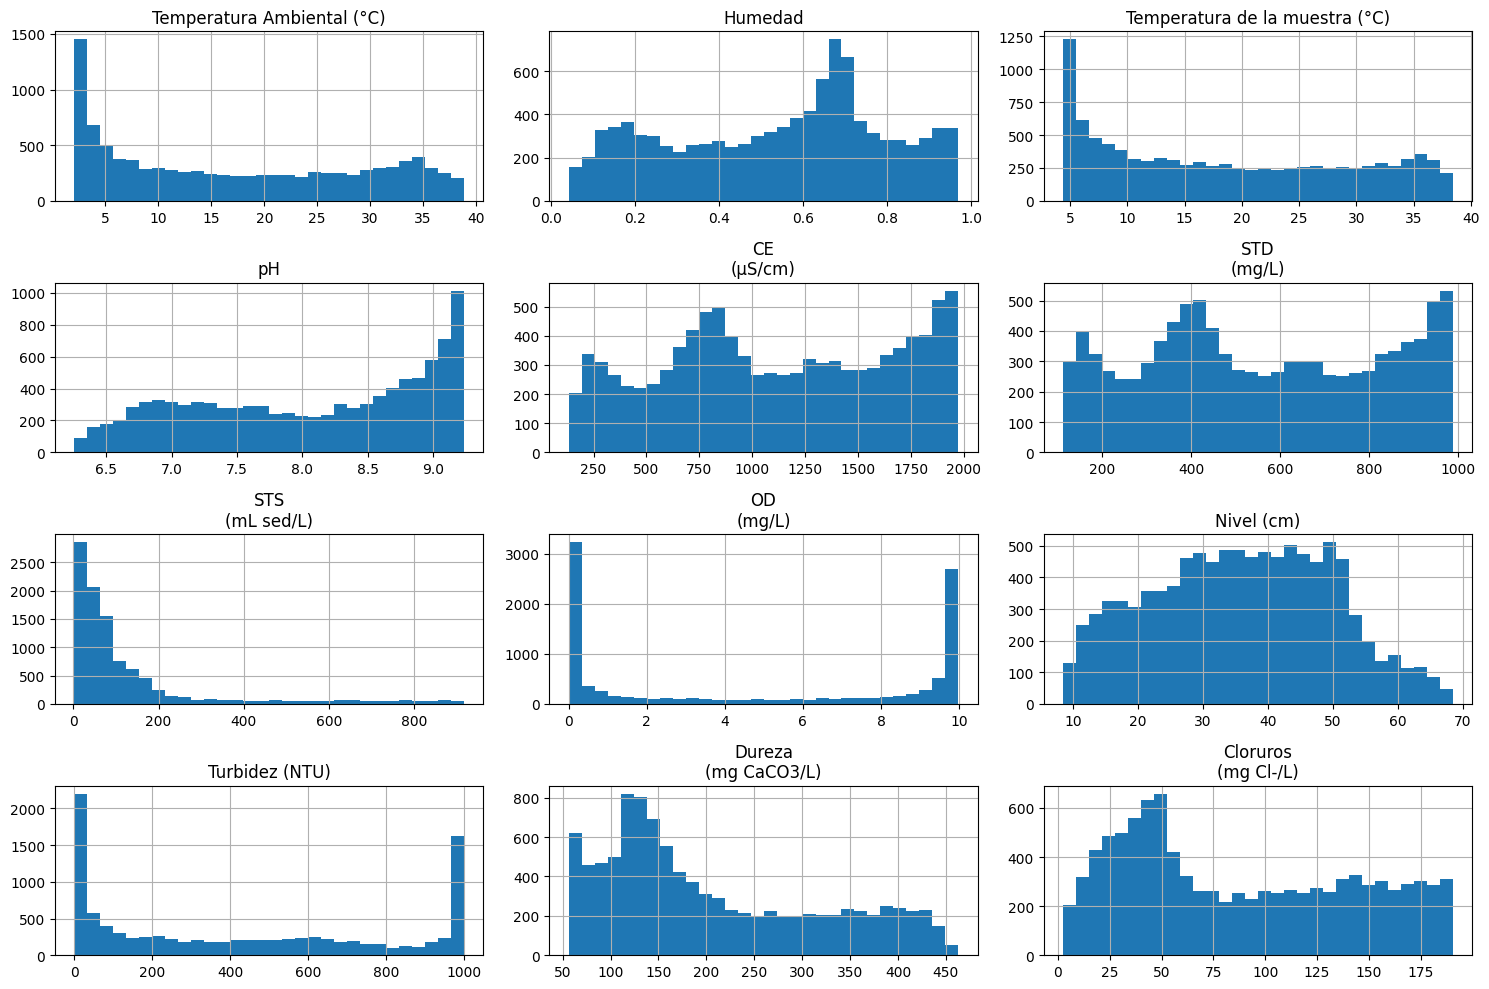

In [18]:
def plot_histograms(df, bins=30, figsize=(15, 10)):
    """
    Genera histogramas para cada columna del DataFrame.
    
    Parámetros:
    df (DataFrame): El DataFrame con los datos a visualizar.
    bins (int): Número de bins para los histogramas.
    figsize (tuple): Tamaño de la figura para los histogramas.
    """
    df.hist(bins=bins, figsize=figsize)
    plt.tight_layout()
    plt.show()

# Llamada a la función con el DataFrame generado
plot_histograms(gen_df)

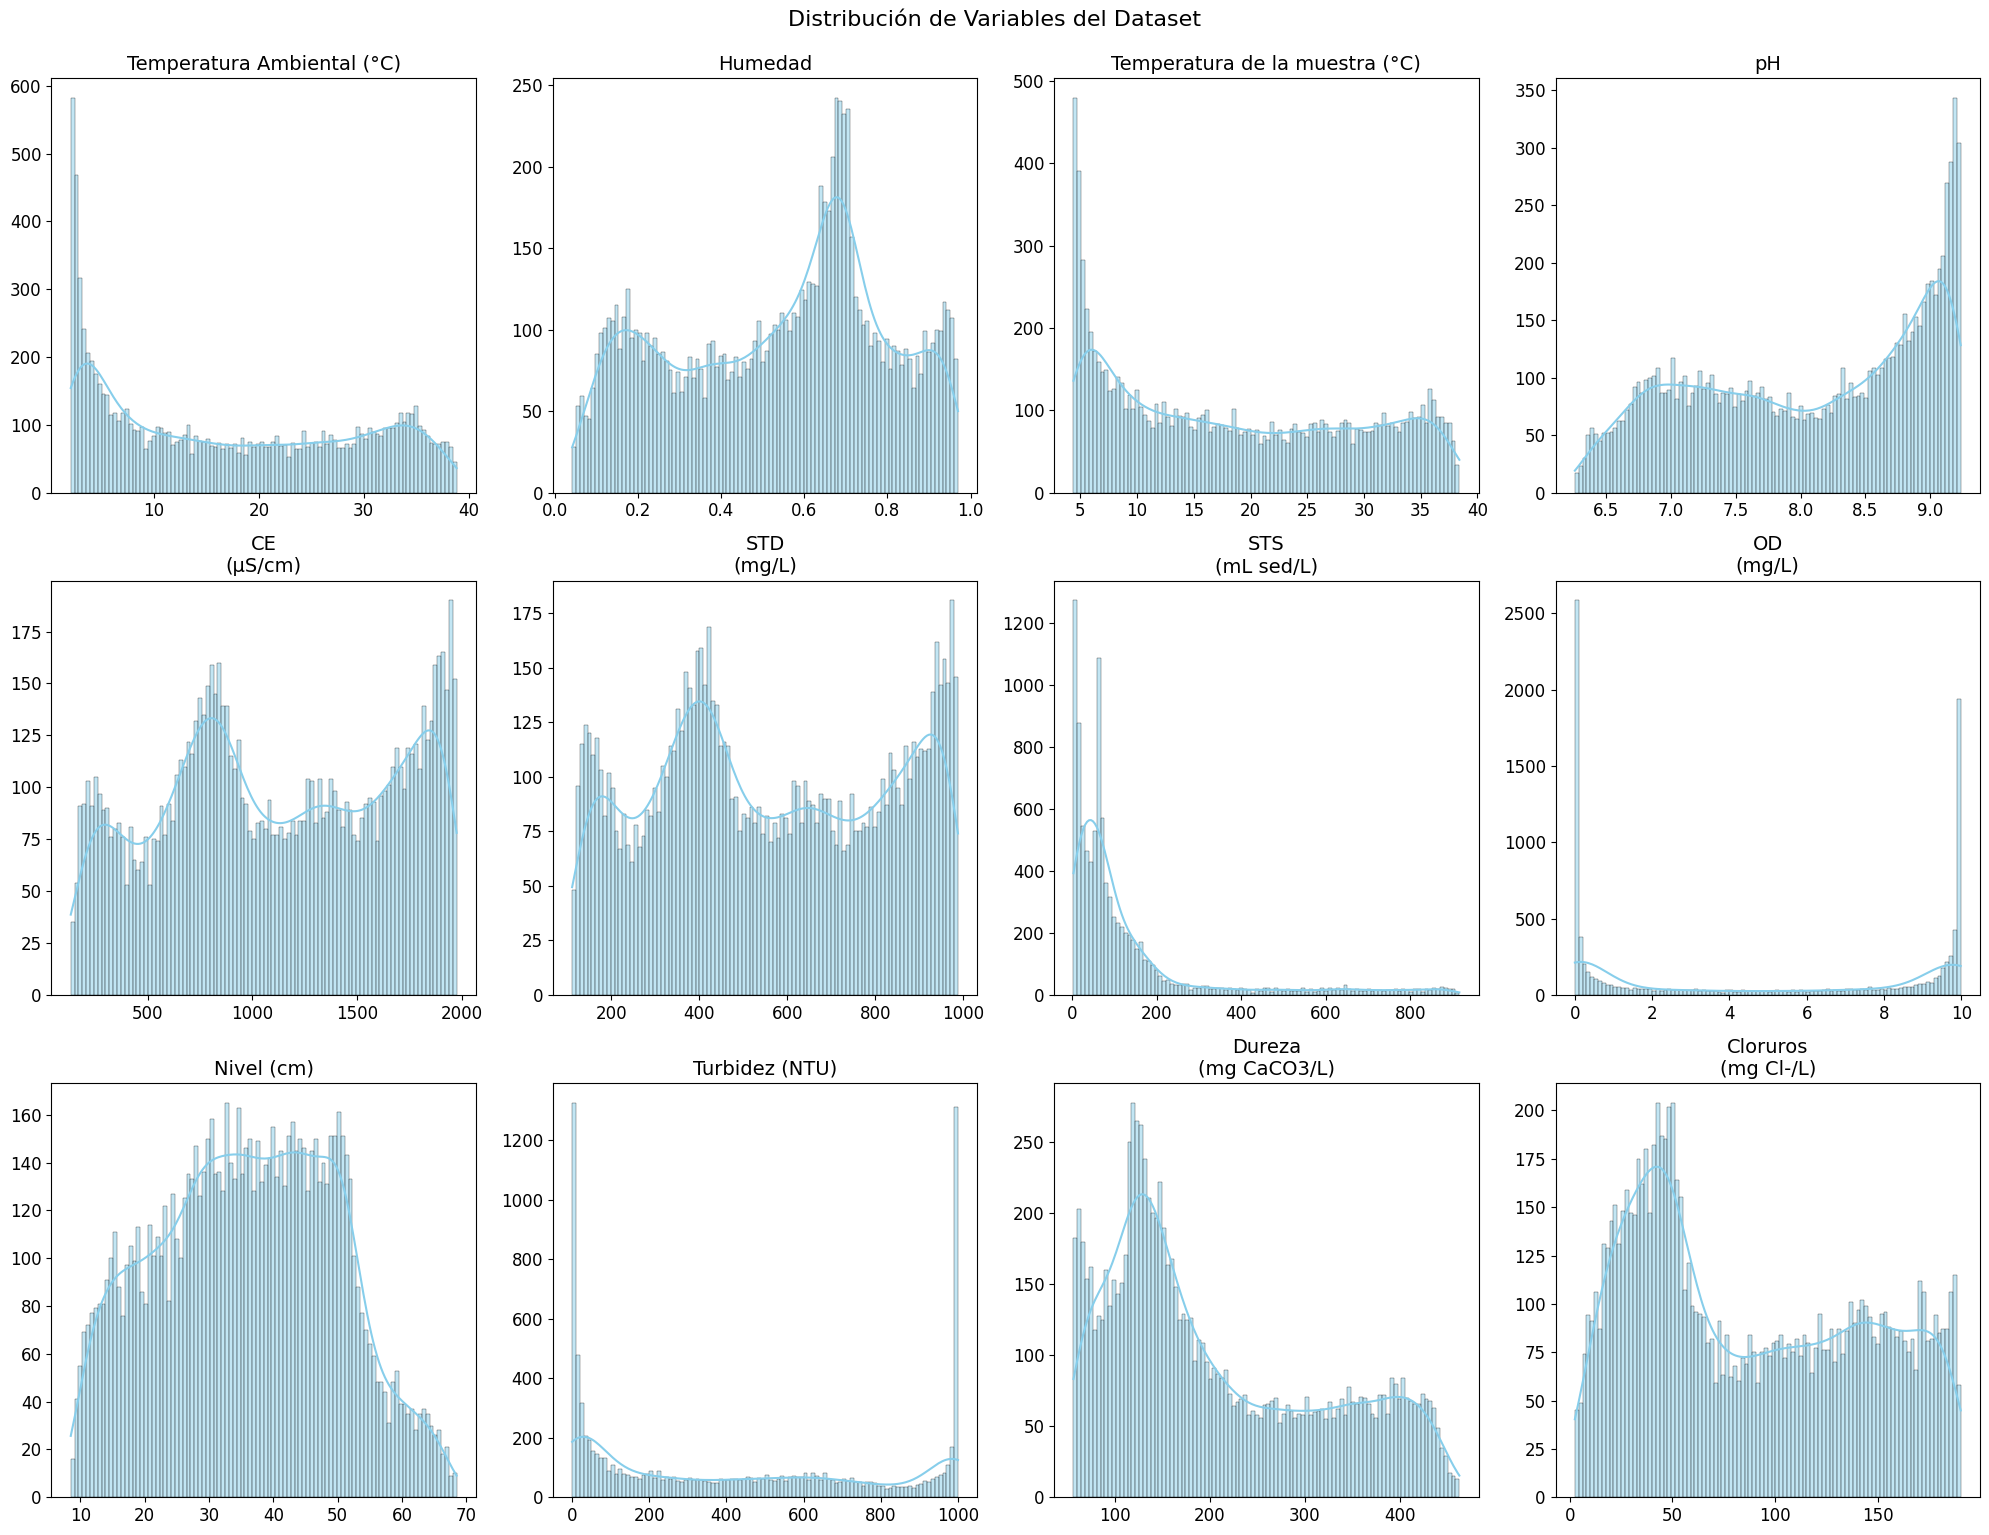

In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_results(df: pd.DataFrame) -> None:
    """
    Función que grafica el histograma de cada columna del dataframe.
    """
    # Determinar el número de columnas en los datos
    n_cols = len(df.columns)

    # Calcular el número de filas necesarias para los subplots
    n_rows = int(np.ceil(n_cols / 4))

    # Crear una figura y una cuadrícula de subplots
    fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(20, 5 * n_rows))

    # Aplanar la matriz de ejes para un indexado más fácil
    axes_flat = axes.flatten() if n_rows > 1 else axes

    # Eliminar cualquier subplot sobrante
    for i in range(n_cols, len(axes_flat)):
        fig.delaxes(axes_flat[i])

    # Crear histogramas
    for i, col in enumerate(df.columns):
        ax = axes_flat[i]
        sns.histplot(df[col], bins=100, color='skyblue', kde=True, ax=ax)  # Ajuste del número de bins a 100
        ax.set_title(f'{col}', fontsize=14)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)

    # Mejorar la disposición
    plt.tight_layout()
    plt.suptitle('Distribución de Variables del Dataset', fontsize=16, y=1.02)
    plt.show()

# Llamada a la función con el DataFrame generado
plot_results(gen_df)


In [22]:
min_max_info(df_sin_nulos)

,name,mins,maxs
0,Temperatura Ambiental (°C),12.80,30.50
1,Humedad,0.19,0.87
2,Temperatura de la muestra (°C),15.10,28.10
3,pH,7.30,8.70
4,CE\n(µS/cm),200.00,1710.00
5,STD\n(mg/L),140.00,850.00
6,STS\n(mL sed/L),1.00,620.00
7,OD\n(mg/L),0.00,9.12
8,Nivel (cm),10.00,70.00
9,Turbidez (NTU),1.06,1000.00


In [23]:
min_max_info(gen_df)

,name,mins,maxs
0,Temperatura Ambiental (°C),2.069281,38.859566
1,Humedad,0.041593,0.969755
2,Temperatura de la muestra (°C),4.387923,38.416260
3,pH,6.256242,9.235937
4,CE\n(µS/cm),132.754700,1974.176636
5,STD\n(mg/L),111.383530,987.962585
6,STS\n(mL sed/L),2.520510,916.126343
7,OD\n(mg/L),0.000011,9.983793
8,Nivel (cm),8.486732,68.498726
9,Turbidez (NTU),0.452712,999.994446


In [24]:
colors = encoder.predict(dataset)
colored_dataset = df_sin_nulos.copy() #copio el dataset original y lo coloreo con el clsificador (encoder)



def color_row(row, color_vector):
    color_rgb = tuple((color_vector*255).astype(np.int16))
    color_hex = '#{:02X}{:02X}{:02X}'.format(color_rgb[0], color_rgb[1], color_rgb[2])
    return [f'background-color: {color_hex};' for _ in row.index]

# Create an iterator for the colors
color_iterator = iter(colors)

# Apply colors to each row
styled_df = colored_dataset.style.apply(lambda row: color_row(row, next(color_iterator)), axis=1)
styled_df.to_excel("colored_dataset_3_neuronas.xlsx", engine='openpyxl')


6/6 [==============================] - 0s 739us/step
